# **Taller 2 Estructuras de Control en Python**
Juan Manuel Rosero García

In [91]:
#@title Completar el código para aproximar la función Sen(x) por series
def suma_seno(x, tol=1e-8, max_iter=200):
    term = x
    total = x
    n = 0

    for i in range(max_iter):
        n += 1
        term = -term * x**2 / (2*n * (2*n + 1))
        total = total + term

        if abs(term) < tol * max(1.0,abs(total)):
            break

    return total, i + 1

In [92]:
#@title Tabla de Convergencia para valores entre 0 y 4$\pi$
#Importo las librerias necesarias
import numpy as np          #Librería para calculo numérico
import math                 #Librería para funciones

#Mostramos la tabla de Convergencia
print(f"{'x':>6} {'imax':>6} {'suma':>16} {'error relativo':>16}")

#Ponemos a prueba el algoritmo con estos valores
for x in [0.5, 1.5, 4.0, 6.3, 7.4, 9.8, 12.2]:
    approx, iters = suma_seno(x)
    exacto = math.sin(x)
    #Calculamos el error relativo
    error_relativo = abs(approx - exacto) / abs(exacto)
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")

     x   imax             suma   error relativo
  0.50      4     0.4794255386         2.55e-11
  1.50      7     0.9974949866         2.76e-12
  4.00     11    -0.7568024954         9.38e-11
  6.30     15     0.0168139005         1.58e-09
  7.40     16     0.8987080961         2.74e-10
  9.80     20    -0.3664791292         1.80e-10
 12.20     23    -0.3582292825         7.42e-10


#**Comparación con la Tolerancia**
Tal como se ve reflejado en la tabla de convergencia, todos los errores relativos están por debajo de la tolerancia, la cuál definimos como $tol=10^{-8}$. Aunque todos los casos cumplieron el criterio de parada, a medida que aumenta los valores de $x$, el error relativo va aumentando.

Esto se explica porque el sistema requiere de más iteraciones para cumplir con la tolerancia, pero este proceso va arrastrando errores por cada cálculo que se realiza, pues el computador no guarda todos los dígitos de cada operacion por lo que las aproximaciones van sumando más errores. Por el otro lado, los valores pequeños de x requieren menos iteraciones y no suman tantos errores por aproximaciones, es por esto que el valor más pequeño de error relativo se evidencio en $x=1.5$ con un error de $2.76 \times 10^{12}$ y el mayor error de $1.58 \times 10^{9}$ para $x=6.3$.

In [93]:
#@title Evaluando el código para un valor grande de x
x_grande = 100.0          #Definimos el valor en dónde vamos a evaluar la función y a hacer la aprox.
approx, iters = suma_seno(x_grande)       #Hallamos el valor aprox y la cantidad de iteraciones
exacto = math.sin(x_grande)               #Calculamos el valor real

print(f"x = {x_grande}")
print(f"Aproximado : {approx}")
print(f"Exacto     : {exacto}")
print(f"Iteraciones: {iters}")
print(f"Error relativo: {abs(approx - exacto) / abs(exacto):.2e}")

x = 100.0
Aproximado : -8.261375671717164e+25
Exacto     : -0.5063656411097588
Iteraciones: 111
Error relativo: 1.63e+26


#**Explicación para valores grandes en la aproximación**
Para valores muy grandres, la serie alcanza valores muy grandes que bajan masivamente la precisión, acumulando un error masivo. Esto hace que el valor diverge a valores de magnitud de $10^{25}$ y para este punto, el criterio de parada se cumple pensando que ya alcanzó la precisión deseada.

In [94]:
#@title Aproximación de una versión Ingenua
def suma_seno_ingenua(x, tol=1e-8, max_iter=200):
    total = 0.0
    for n in range(max_iter):
        term = ((-1)**n) * (x**(2*n + 1)) / math.factorial(2*n + 1)
        total += term
        if abs(term) < tol * max(1.0, abs(total)):
            break
    return total, n + 1

# Comparación directa de resultados
print(f"{'x':>6} {'Recursivo':>16} {'Ingenuo':>16} {'Diferencia':>14}")

for x in [0.5, 2.0, 4.0, 7.0, 9.5, 12.4, 15.0]:
    # Guardamos tanto el resultado como las iteraciones de cada función
    res_rec, iters_r = suma_seno(x)
    res_ing, iters_i = suma_seno_ingenua(x)

    diferencia = abs(res_rec - res_ing)
    print(f"{x:6.1f} {res_rec:16.10f} {res_ing:16.10f} {diferencia:14.2e}")

     x        Recursivo          Ingenuo     Diferencia
   0.5     0.4794255386     0.4794255386       0.00e+00
   2.0     0.9092974268     0.9092974268       0.00e+00
   4.0    -0.7568024954    -0.7568024954       0.00e+00
   7.0     0.6569865988     0.6569865988       8.88e-15
   9.5    -0.0751511208    -0.0751511208       1.52e-14
  12.4    -0.1656041760    -0.1656041760       1.30e-12
  15.0     0.6502878399     0.6502878399       3.20e-11


In [95]:
#@title Aproximación con reducción del argumento
def suma_seno_reducida(x, tol=1e-8, max_iter=200):
    x_reducido = math.remainder(x, 2 * math.pi)
    return suma_seno(x_reducido, tol, max_iter)

for x in [0.5, 2.0, 4.0, 7.0, 9.5, 12.4, 15.0]:
    approx_red, _ = suma_seno_reducida(x)
    exacto = math.sin(x)
    diferencia_red = abs(approx_red - exacto)
    print(f"x={x:8.1f}   aproximado={approx_red: .10f}   exacto={exacto: .10f}    diferencia={diferencia_red: 8.3e}")


x=     0.5   aproximado= 0.4794255386   exacto= 0.4794255386    diferencia= 1.221e-11
x=     2.0   aproximado= 0.9092974268   exacto= 0.9092974268    diferencia= 4.269e-12
x=     4.0   aproximado=-0.7568024954   exacto=-0.7568024953    diferencia= 5.270e-11
x=     7.0   aproximado= 0.6569865987   exacto= 0.6569865987    diferencia= 2.113e-12
x=     9.5   aproximado=-0.0751511205   exacto=-0.0751511205    diferencia= 5.931e-12
x=    12.4   aproximado=-0.1656041754   exacto=-0.1656041754    diferencia= 2.695e-13
x=    15.0   aproximado= 0.6502878402   exacto= 0.6502878402    diferencia= 2.500e-12


#**Comparación con la Versión Ingenua**
La diferencia de precisión comienza a darse a partir de $x=7.0$ y va creciendo a medida que $x$ crece. La divergencia entre la versión recursiva y la ingenua se debe a que la segunda requiere hacer más cálculos, pues recalcula potencias y factoriales  por lo que requiere más iteraciones que implica más errores de redondeo que la versión recursiva.

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_640/699758363.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(t,N, label=('N(t)=$N_0 e^{-\lambda t}$'))


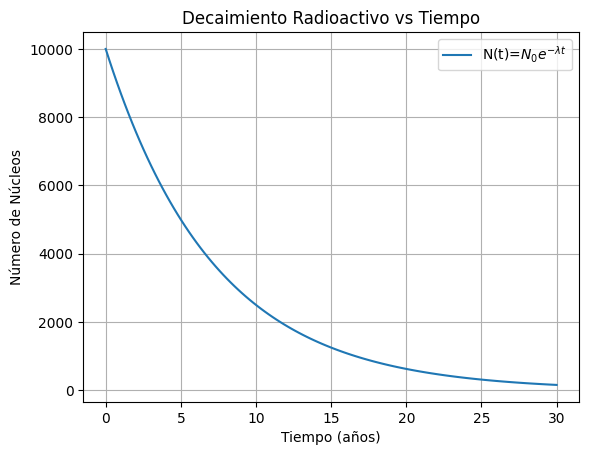

In [96]:
#@title Decaimiento Radioactivo con Python
import matplotlib.pyplot as plt

#Datos iniciales
N_0=10000
t1_2=5
#1. Constante de decaimiento
lamb=np.log(2) / t1_2

#2. Creando el arreglo entre 0 y 30 años
t=np.linspace(0,30,120)

#3. Calculando N sin ciclos
N= N_0 * np.exp(-lamb * t)

#4. Graficando N en función de t
plt.plot(t,N, label=('N(t)=$N_0 e^{-\lambda t}$'))
plt.xlabel('Tiempo (años)')
plt.ylabel('Número de Núcleos')
plt.title('Decaimiento Radioactivo vs Tiempo')
plt.legend()
plt.grid()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_640/1082895018.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(t,N, label=('N(t)=$N_0 e^{-\lambda t}$'))


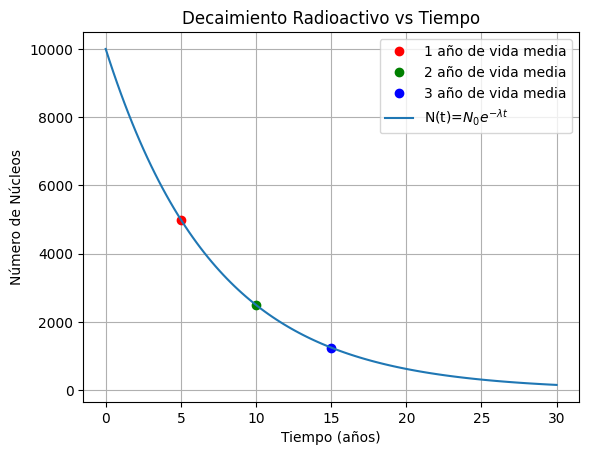

In [97]:
#5. Puntos para 1, 2, y 3 vidas medias
t_k = np.array([1, 2, 3]) * t1_2
N_k = N_0 * (0.5)**np.array([1, 2, 3])

# Grafica los 3 puntos sobre la curva que ya hicimos antes también
plt.plot(t_k[0], N_k[0], 'ro', label='1 año de vida media')
plt.plot(t_k[1], N_k[1], 'go', label='2 año de vida media')
plt.plot(t_k[2], N_k[2], 'bo', label='3 año de vida media')
plt.plot(t,N, label=('N(t)=$N_0 e^{-\lambda t}$'))
plt.xlabel('Tiempo (años)')
plt.ylabel('Número de Núcleos')
plt.title('Decaimiento Radioactivo vs Tiempo')
plt.legend()
plt.grid()
plt.show()

#**Observar que fracción de la muestra permanece**
Tomando la ecuación del decaimiento radioactivo, observemos que:

$$
N(t)=N_0 e^{- \lambda t} , \ k=\frac{\ln(2)}{t_{1/2}}  \\
\Rightarrow N(t)= N_0 e^{- \frac{\ln(2)t}{t_{1/2}}} \\
\Rightarrow N(t)= N_0 (\frac{1}{2})^{\frac{t}{t_{1/2}}} , \ t=k t_{1/2} \\
\Rightarrow \frac{N(t)}{N_0}=(\frac{1}{2})^k \\
$$
A continuación calculamos la fracción que permanece:

In [98]:
#@title Cálculo de las fracciones de la muestra
k = np.array([1, 2, 3])

# Fracción que permanece
fracciones = (0.5)**k

#Muestro el resultado :D
print(f"Fracciones tras 1, 2 y 3 vidas medias: {fracciones}")

Fracciones tras 1, 2 y 3 vidas medias: [0.5   0.25  0.125]


In [99]:
#@title Cálculo del tiempo en el cuál permanece cierto porcentaje de la prueba inicial
lambda_n = np.log(2) / t1_2

# Porcentajes deseados expresados como fracción
porcentajes = np.array([0.50, 0.25, 0.10])

# Despeje vectorizado del tiempo
tiempos = -np.log(porcentajes) / lambda_n

print(f"Tiempo para el 50%: {tiempos[0]:.2f} años")
print(f"Tiempo para el 25%: {tiempos[1]:.2f} años")
print(f"Tiempo para el 10%: {tiempos[2]:.2f} años")

Tiempo para el 50%: 5.00 años
Tiempo para el 25%: 10.00 años
Tiempo para el 10%: 16.61 años


#**MOMENTO DE LAS VERIFICACIONES**

In [100]:
#@title Verificación para la Parte A
casos_a = [                                         # Lista de (x, valor_esperado, tolerancia)
    (0.5, math.sin(0.5), 1e-8),                     # Caso estándar de convergencia rápida
    (100.0, math.sin(100.0), 1e-6),                 # Caso x grande positivo
    (-237.0, math.sin(-237.0), 1e-6),               # Caso x grande negativo
]

for x, esperado, tol in casos_a:
    obtenido, _ = suma_seno_reducida(x)
    ok = abs(obtenido - esperado) < tol
    estado = "PASS" if ok else "FAIL"
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10f}   esperado={esperado: .10f}")

PASS  x=     0.5   obtenido= 0.4794255386   esperado= 0.4794255386
PASS  x=   100.0   obtenido=-0.5063656411   esperado=-0.5063656411
PASS  x=  -237.0   obtenido= 0.9819578697   esperado= 0.9819578698


In [101]:
#@title Verificación para la Parte B
def N_decaimiento(t, N0=10000, t_half=5.0):
    lambda_decay = np.log(2) / t_half
    return N0 * np.exp(-lambda_decay * t)

casos_b = [         # Lista de (t, fracción_esperada)
    (0.0, 1.00),    # En t=0 debe quedar toda de la muestra.
    (5.0, 0.50),    # En t = t_1/2  debe quedar la mitad.
    (10.0, 0.25),   # En t = 2*t_1/2 debe quedar el 1/4.
]

for t, fraccion_esperada in casos_b:
    try:
        obtenido = N_decaimiento(t) / 10000         # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:
        print(f"FAIL  t={t:>5.1f} años   ({e})")

PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250
